In [2]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

# **실습 : vanilla GAN 모델 만들기**

## **Import Module**

In [3]:
%%capture
!pip -q install torchmetrics torchinfo

In [4]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

# import lightning as L
# from lightning.pytorch import Trainer
# from lightning.pytorch.callbacks import ModelCheckpoint
# from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__#,L.__version__

'2.8.0+cu126'

In [5]:
# # # gdriver mount to load saved model

## **DataSet**

### 라벨있는 샘플 데이타 생성

Label:tensor([1], dtype=torch.int32)


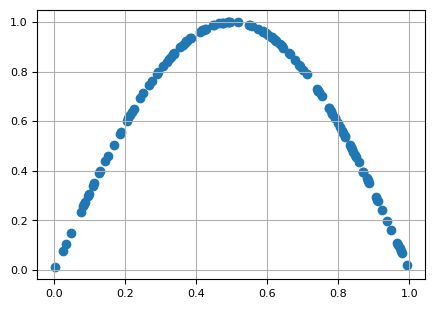

In [6]:
# generate n real samples with class labels
def real_samples(n):
    X1 = torch.rand(n).view(-1,1) #uniform random
    X2 = torch.sin(X1*torch.pi).view(-1,1)
    X = torch.hstack((X1,X2))     #(n,2)
    y = torch.ones((n,1))         # True
    y = y.type(torch.int)
    return X, y   #((n,2),(n,1))

# plot real samples
# 순서가 random인 sin curve의 일부
data = real_samples(128)
print(f'Label:{data[1][0]}')
plt.scatter(data[0][:, 0], data[0][:, 1])
plt.grid()
plt.show()

## **GAN 모델링**

### 판별기 (discriminator)

In [7]:
# Discriminator model
class D_model(nn.Module):
    def __init__(self, n_inputs=2):
        super(D_model, self).__init__()
        self.discriminator = nn.Sequential(
            nn.Linear(n_inputs, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
            nn.Sigmoid(), )

    def forward(self, x):
        out = self.discriminator(x)
        return out

D = D_model()
summary(D, input_size=(8, 2))

Layer (type:depth-idx)                   Output Shape              Param #
D_model                                  [8, 1]                    --
├─Sequential: 1-1                        [8, 1]                    --
│    └─Linear: 2-1                       [8, 32]                   96
│    └─ReLU: 2-2                         [8, 32]                   --
│    └─Dropout: 2-3                      [8, 32]                   --
│    └─Linear: 2-4                       [8, 1]                    33
│    └─Sigmoid: 2-5                      [8, 1]                    --
Total params: 129
Trainable params: 129
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### 생성기 (generator)


In [8]:
latent_dim = 5
# Generator model
class G_model(nn.Module):
    def __init__(self, n_outputs=2):
        super(G_model, self).__init__()
        self.generator = nn.Sequential(
            nn.Linear(latent_dim, 16), #Linear(5, 16)
            nn.ReLU(),
            nn.Linear(16, n_outputs),
#            nn.Sigmoid(),
            nn.Tanh(),
            )

    def forward(self, x):
        out = self.generator(x.to(device))
        return out

G = G_model()
summary(G, input_size=(8, 5))

Layer (type:depth-idx)                   Output Shape              Param #
G_model                                  [8, 2]                    --
├─Sequential: 1-1                        [8, 2]                    --
│    └─Linear: 2-1                       [8, 16]                   96
│    └─ReLU: 2-2                         [8, 16]                   --
│    └─Linear: 2-3                       [8, 2]                    34
│    └─Tanh: 2-4                         [8, 2]                    --
Total params: 130
Trainable params: 130
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### 잠재공간에서 샘플링(생성기 입력을 위한)


In [9]:
# generate points in latent space as input for the generator
def latent_points(n):
    x = torch.randn((n, latent_dim))
    return x.to(device)

latent_points(2)

tensor([[ 1.9137, -0.8940, -0.9390,  0.8355, -0.1265],
        [ 0.7579, -1.2420,  0.2656,  1.5458,  0.1093]], device='cuda:0')

### 생성기가 가짜 샘플을 생성

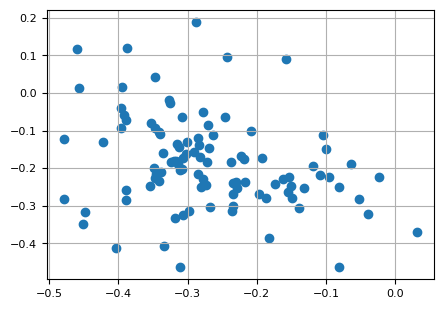

In [10]:
# use the generator to generate n fake examples, with class labels
def generate_fake_samples(generator, n):
    x = latent_points(n)  #(n,5)
    x = generator(x)      #(n,2)<-(n,5)
    x = x.cpu().detach()
    y = torch.zeros(n, 1) #False
    return x, y 	        #(n,2),(n,1)

# plot fake samples
data = generate_fake_samples(G, 100)
plt.scatter(data[0][:, 0], data[0][:, 1])
plt.grid()
plt.show()

### 판별기 성능 검증 및 진짜와 가짜의 위치 시각화

Epoch:0   Acc_real:1.00   Acc_fake:0.01


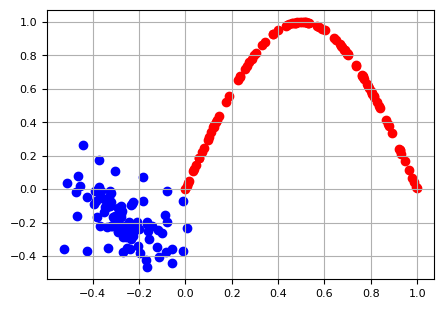

(tensor(1.), tensor(0.0100))

In [11]:
# evaluate the discriminator and plot real and fake points
def summarize_performance(epoch, generator, discriminator, n=100 ):
    # real samples
    x_real, y_real = real_samples(n)
    # evaluate for real acc.
    y_real_pred = discriminator(x_real.to(device))
    acc_real = FM.accuracy(y_real_pred.cpu(), y_real, task='binary', num_classes=2 )

    # fake examples
    x_fake, y_fake = generate_fake_samples(generator, n)
    # evaluate for fake acc.
    y_fake_pred = discriminator(x_fake.to(device))
    acc_fake = FM.accuracy(y_fake_pred.cpu(), y_fake.type(torch.int), task='binary', num_classes=2)

    # summarize discriminator performance
    print(f"Epoch:{epoch}   Acc_real:{acc_real:.2f}   Acc_fake:{acc_fake:.2f}")
    # scatter plot real and fake data points
    plt.scatter(x_real[:, 0], x_real[:, 1], color='red')
    plt.scatter(x_fake[:, 0], x_fake[:, 1], color='blue')
    plt.grid()
    plt.show()
    return (acc_real,acc_fake)

summarize_performance(0, G, D)

## 생성기와 판별기 학습 및 결과

In [12]:
class RealSampleData(Dataset):
    def __init__(self, num_samples):
        self.num_samples = num_samples
        self.X, self.y = real_samples(num_samples)
    def __len__(self):
        return self.num_samples
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [13]:
batch_size = 512
realDataset = RealSampleData(batch_size)
realLoader = DataLoader(realDataset, batch_size=batch_size, shuffle=True)

In [14]:
G = G_model().to(device)
D = D_model().to(device)

lr = 0.0005
loss_function = nn.BCELoss()
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr)
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr)

Epoch:0   Acc_real:0.44   Acc_fake:0.71


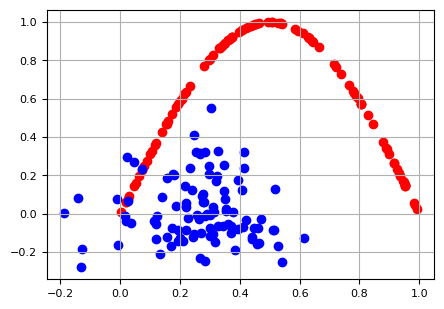

Epoch:500   Acc_real:0.59   Acc_fake:0.86


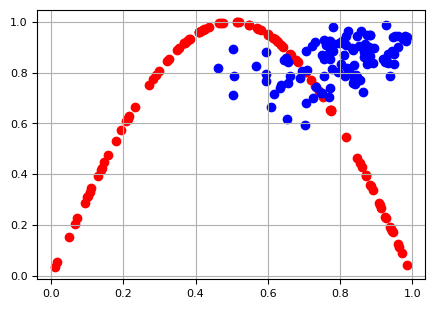

Epoch:1000   Acc_real:0.14   Acc_fake:0.82


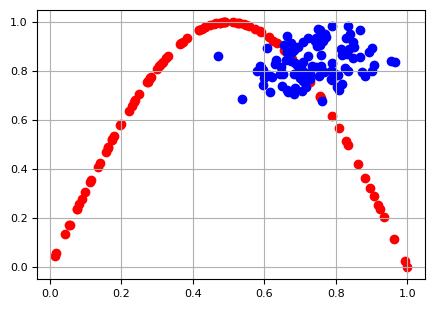

Epoch:1500   Acc_real:0.56   Acc_fake:0.52


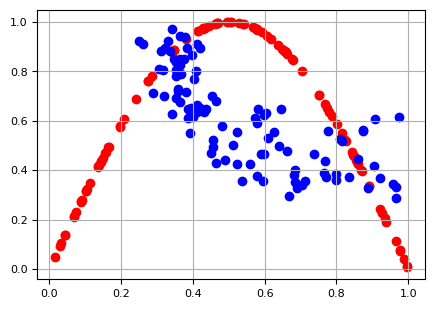

Epoch:2000   Acc_real:0.40   Acc_fake:0.54


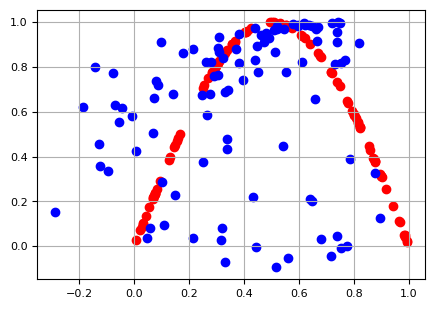

Epoch:2500   Acc_real:0.53   Acc_fake:0.50


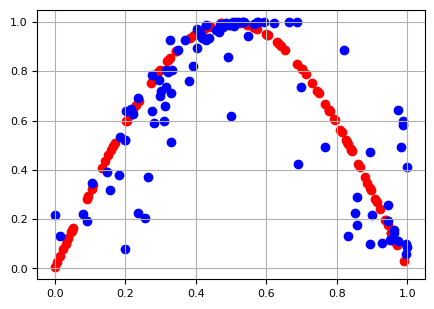

Epoch:3000   Acc_real:0.43   Acc_fake:0.63


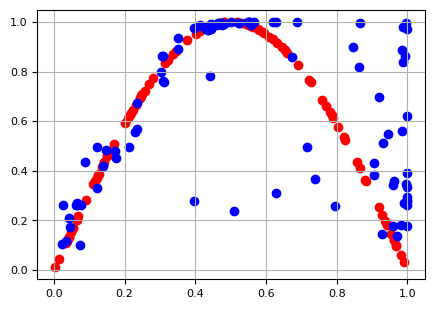

Epoch:3500   Acc_real:0.52   Acc_fake:0.48


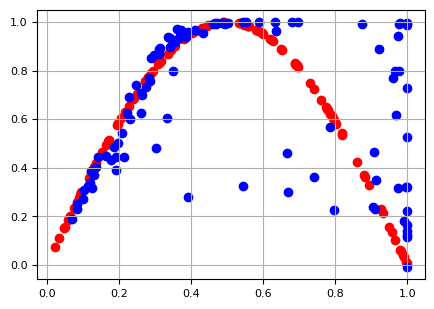

Epoch:4000   Acc_real:0.44   Acc_fake:0.56


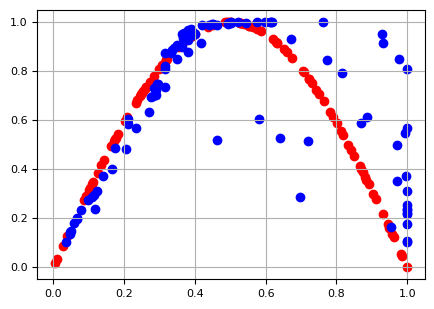

Epoch:4500   Acc_real:0.51   Acc_fake:0.49


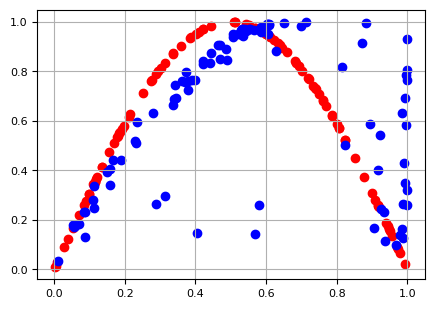

Epoch:5000   Acc_real:0.55   Acc_fake:0.60


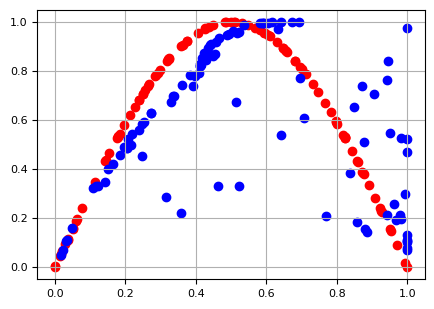

Epoch:5500   Acc_real:0.57   Acc_fake:0.65


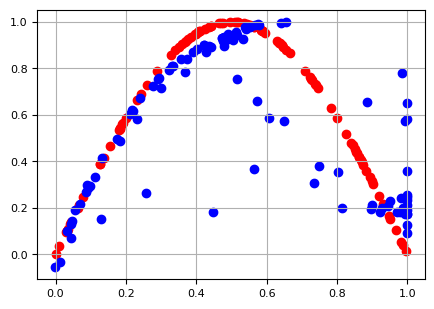

Epoch:6000   Acc_real:0.43   Acc_fake:0.83


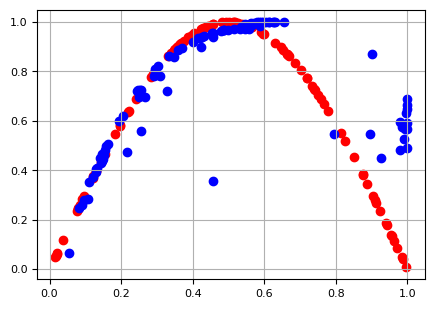

Epoch:6500   Acc_real:0.53   Acc_fake:0.69


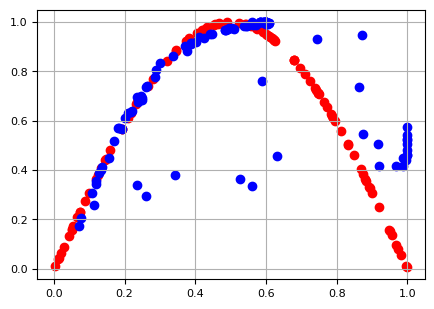

Epoch:7000   Acc_real:0.68   Acc_fake:0.53


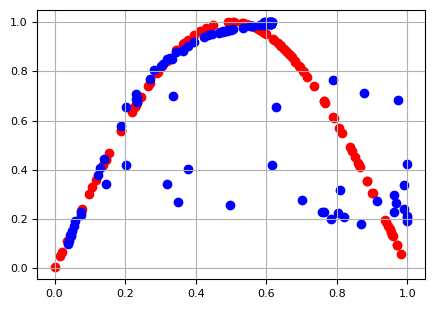

Epoch:7500   Acc_real:0.54   Acc_fake:0.70


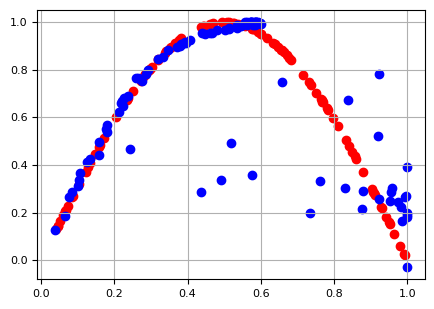

Epoch:8000   Acc_real:0.60   Acc_fake:0.68


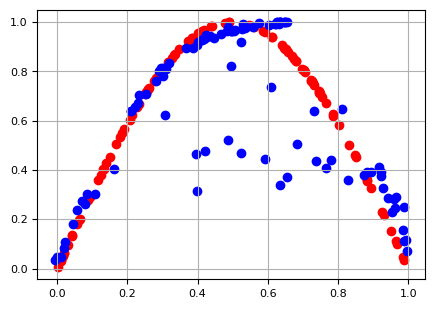

Epoch:8500   Acc_real:0.61   Acc_fake:0.62


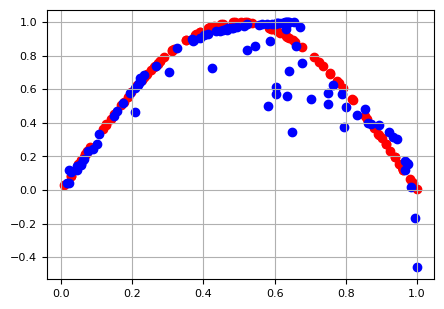

Epoch:9000   Acc_real:0.53   Acc_fake:0.64


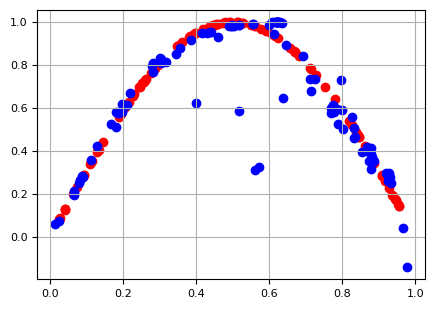

Epoch:9500   Acc_real:0.49   Acc_fake:0.51


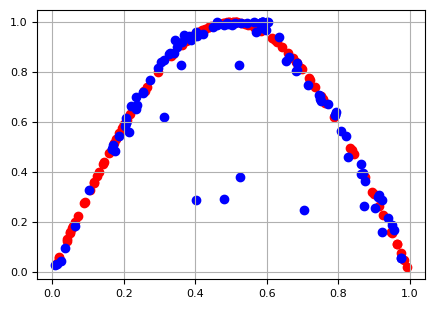

Epoch:10000   Acc_real:0.48   Acc_fake:0.51


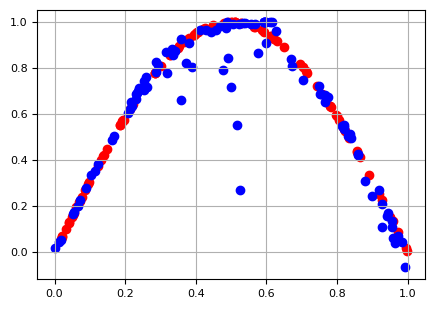

Epoch:10500   Acc_real:0.49   Acc_fake:0.47


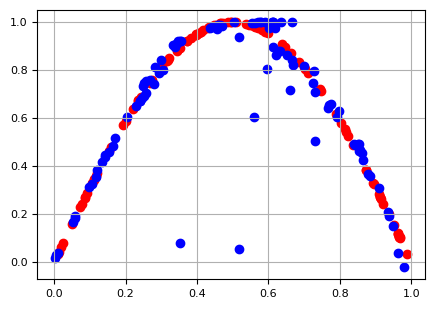

Epoch:11000   Acc_real:0.73   Acc_fake:0.34


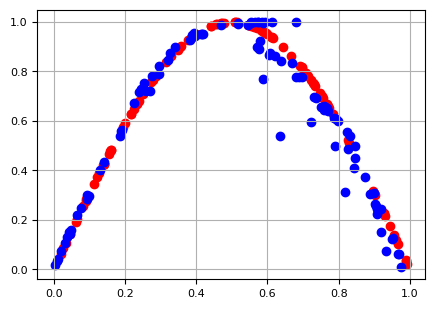

Epoch:11500   Acc_real:0.69   Acc_fake:0.47


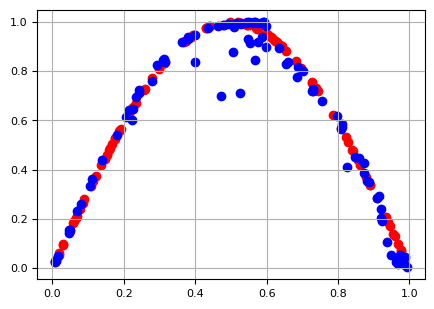

Epoch:12000   Acc_real:0.65   Acc_fake:0.41


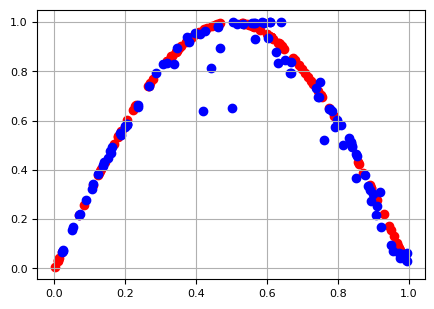

Epoch:12500   Acc_real:0.62   Acc_fake:0.45


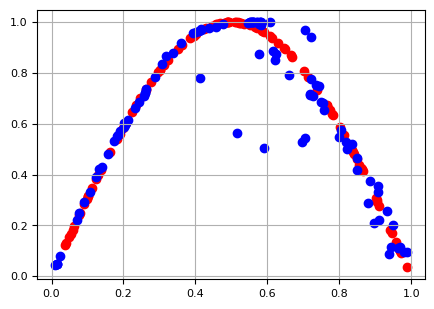

Epoch:13000   Acc_real:0.61   Acc_fake:0.41


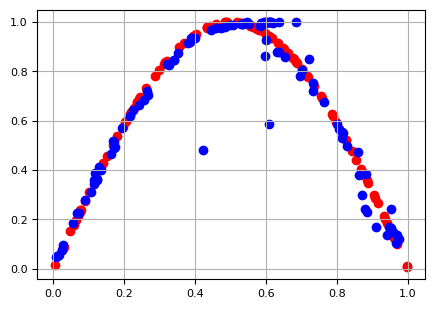

Epoch:13500   Acc_real:0.63   Acc_fake:0.46


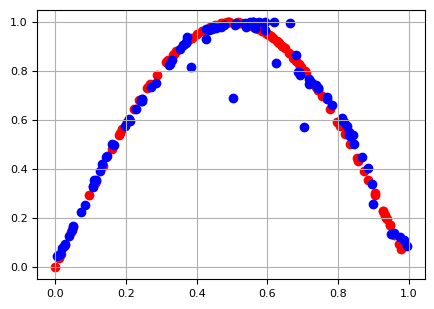

Epoch:14000   Acc_real:0.64   Acc_fake:0.46


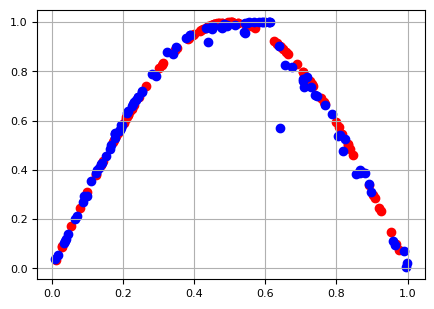

Epoch:14500   Acc_real:0.63   Acc_fake:0.41


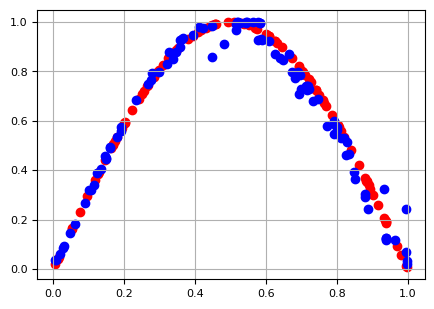

CPU times: user 1min 58s, sys: 1.49 s, total: 2min
Wall time: 2min


In [15]:
%%time
num_epochs = 15000
losses_d = []
losses_g = []
acc_real = []
acc_fake= []
for epoch in range(num_epochs):
    for n, (r_samples, r_labels) in enumerate(realLoader):
        ## Data for training the discriminator
        f_samples,f_labels =  generate_fake_samples(G, batch_size)
        all_samples = torch.cat((r_samples, f_samples))
        all_labels = torch.cat((r_labels, f_labels))
        ## Training the discriminator
#        D.zero_grad()
        optimizer_D.zero_grad()
        output_d = D(all_samples.to(device))
        loss_d = loss_function(output_d.cpu(), all_labels)

        acc_real.append(FM.accuracy(output_d[:batch_size].cpu(), r_labels, task='binary', num_classes=2))
        acc_fake.append(FM.accuracy(output_d[batch_size:].cpu(), f_labels, task='binary', num_classes=2 ))

        loss_d.backward()
        optimizer_D.step()
        losses_d.append(loss_d)

        ## Data for training the generator
        latent_samples = latent_points(batch_size)
        r_labels = r_labels.type(torch.FloatTensor)
        ## Training the generator
#        G.zero_grad()
        optimizer_G.zero_grad()
        f_samples = G(latent_samples)
        output_d = D(f_samples)
        loss_g = loss_function(output_d.cpu(), r_labels)
        loss_g.backward()
        optimizer_G.step()
        losses_g.append(loss_g)

    # Show loss
    if epoch % 500 == 0:
        # print(f"Epoch: {epoch} Loss D.: {loss_d:.2f}")
        # print(f"Epoch: {epoch} Loss G.: {loss_g:.2f}")
        summarize_performance(epoch, G, D)
# Wall time: 2min 1s

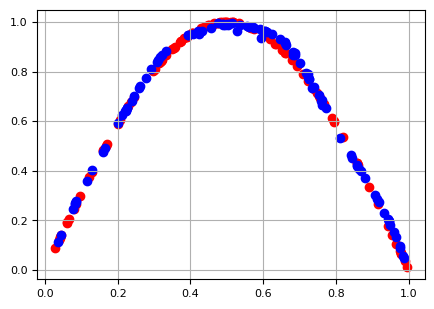

In [1]:
plt.plot(np.array([i.detach() for i in acc_fake]), label="acc fake",linewidth=0.3)
plt.plot(np.array([i.detach() for i in acc_real]), label="acc real",linewidth=0.3)
plt.ylim(0,1)
plt.grid()
plt.legend()
plt.show()

NameError: name 'plt' is not defined

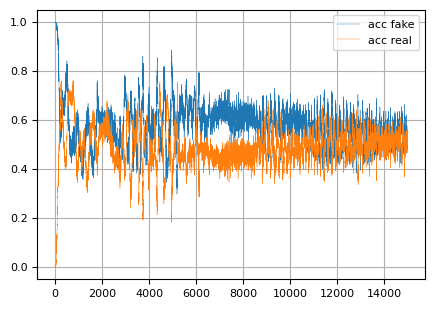

In [ ]:
plt.plot(np.array([i.detach() for i in losses_g]), label="G loss",linewidth=0.3)
plt.plot(np.array([i.detach() for i in losses_d]), label="D loss",linewidth=0.3)
plt.ylim(0.6,0.8)
plt.grid()
plt.legend()
plt.show()

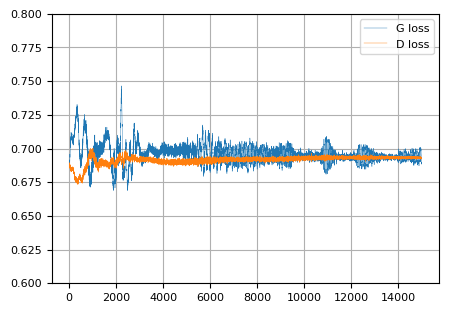

- Model save

In [ ]:
# path="./models/" ###
# os.makedirs(path, exist_ok=True)

In [ ]:
# torch.save(G, path+"vanilla_gan_generator.pt")
# torch.save(D, path+"vanilla_gan_discriminator.pt")

- Model load

In [ ]:
# discriminator2 = torch.load(path+'vanilla_gan_discriminator.pt')
# generator2 = torch.load(path+'vanilla_gan_generator.pt')

In [ ]:
#summary(discriminator2, input_size=(8, 2))

In [ ]:
#summary(generator2, input_size=(8, 5))

## **실습 과제**

- ####  더 빠른 학습을 위해 모델을 개선해 보자(GAN 모델은 학습이 쉽지 않음)
- #### Latent space vector를 늘리면? latent_dim = ??
- #### Discriminator, Generator 모델을 더 크게 하면??    
- #### epoch = 3000에서 유사한 수준의 학습이 가능할까?? 시도해 보자  



